In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import cv2
import os
import numpy as np
from typing import List, Dict, Optional
from PipelineMOT.src.feature_extractor import FeatureExtractor
from PipelineMOT.src.detector import Detector
from PipelineMOT.src.tracker import Tracker
from PipelineMOT.src.gtalink import GTALink
from PipelineMOT.src.compute_metrics import compute_metrics

In [2]:
BASE = r"D:\UIT 3rd year\NhanDang\Project"
YOLO_PATH    = BASE + r"\PipelineMOT\models\best_yolo26.pt"
RF_PATH      = r"\PipelineMOT\models\best_rf_detr.pth"
#SOLIDER_PATH = r"D:\UITs subject\Năm 3\Nhận dạng\SOLIDER\checkpoints\swin_small_converted.pth"
OUTPUT_DIR   = r"\Output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

ALL_DETECTOR  = ["yolo26", "rf_detr"]
ALL_EXTRACTOR = ["osnet", "solider", "color_histogram"]
ALL_TRACKER   = ["bytetrack", "ocsort", "strongsort", "deepeiou"]

VIDEOS = r"D:\UIT 3rd year\NhanDang\Project\Data\wide_view\videos"
GROUNDTRUTH = r"D:\UIT 3rd year\NhanDang\Project\Data\wide_view\annotations"
ALL_VIDEOS = sorted(os.listdir(VIDEOS))
VAL_VIDEOS = ALL_VIDEOS[18:24]

In [3]:
def run_mot(video_path, detector, tracker, extractor=None, refiner = None, extractor_refine = None):
    """
    Chạy full MOT pipeline cho một video.
 
    Parameters
    ----------
    video_path : str
    detector   : object với method .detect(frame) → [[x1,y1,x2,y2,conf], ...]
    tracker    : Tracker instance
    extractor  : object với method .extract(crop) → np.ndarray (L2-normalised), dùng cho online tracking
    refiner    : (optional) object với .refine(all_tracks) → refined_tracks
                 Nếu None, trả về all_tracks trực tiếp.
    extractor_refine: (optional) object với method .extract(crop) → np.ndarray
                       Extractor riêng để tạo embedding cho refinement.
                       Nếu None nhưng refiner được truyền vào → dùng chung với online tracking
 
    Returns
    -------
    all_tracks : dict
        {
            track_id (int): {
                'boxes' : list — box [x1,y1,x2,y2] hoặc None theo từng frame,
                'frames': list — frame_idx tương ứng (chỉ các frame có box)
            }
        }
    """
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f"Không mở được video: {video_path}")
    
    # all_tracks[track_id]['boxes'][i] = box tại frame i, hoặc None nếu không có
    all_tracks: Dict[int, Dict] = {} 

    frame_idx = 0   # 0-based index để index vào list
    frame_id  = 1   # 1-based id truyền vào tracker (convention của STrack)
    
    # extractor của refiner
    extractor_refine = extractor_refine if (refiner is not None and extractor_refine is not None) else extractor
    
    # Duyệt qua từng frame 
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        if frame_idx % 100 == 0:
            print(f"Processing frame {frame_idx}")
        
        # Bước 2.1: Detect
        detections = detector.detect(frame) # Trả về list các box và conf [[x1, y1, x2, y2, conf]]
        
        # Bước 2.2: Crop + Feature
        enriched_detections = [] # Tổng hợp box, conf, feature tại frame đang xét của các object
        for det in detections:
            enriched = {}
            x1, y1, x2, y2 = map(int, det[:-1])
            score = float(det[4])
            
            crop = frame[y1:y2, x1:x2]

            if crop.size == 0:
                continue

            # 2.2.1 Extract feature
            feature = extractor.extract(crop) if extractor is not None else None

            # 2.2.2 attach feature
            enriched_detections.append({
                'tlbr' : [float(x1), float(y1), float(x2), float(y2)],
                'score': score,
                'feat' : feature,
            })

        # Bước 2.3: Tracking
        active_tracks  = tracker.update(enriched_detections, frame_id) 
         
        # Lưu all_tracks
        # Với các track_id mới: chèn None cho tất cả frame trước đó
        active_ids = set()
        for track in active_tracks:
            tid = track.track_id
            active_ids.add(tid)
 
            if tid not in all_tracks:
                # Track mới → fill None cho các frame trước
                entry = {
                    'boxes' : [None] * frame_idx,
                    'frames': [],
                }
                if refiner is not None:
                    entry['feats'] = []         # chỉ khởi tạo khi cần refinement
                all_tracks[tid] = entry
 
            box = track.tlbr.tolist()   # [x1,y1,x2,y2] 
            all_tracks[tid]['boxes'].append(box)
            all_tracks[tid]['frames'].append(frame_idx)
 
            # Nếu cần refine:
            if refiner is not None:
                    x1, y1, x2, y2 = map(int, track.tlbr)
                    # Clamp để tránh ra ngoài biên frame
                    crop = frame[y1:y2, x1:x2]
                    feat = extractor_refine.extract(crop) if crop.size > 0 \
                        else extractor_refine.extract(frame[0:1, 0:1])  # fallback crop rỗng
                    all_tracks[tid]['feats'].append(feat)
                    
        # Track đã có trong dict nhưng không active frame này → None
        for tid, data in all_tracks.items():
            if tid not in active_ids:
                # Chỉ thêm None nếu track chưa có entry cho frame này
                if len(data['boxes']) == frame_idx:
                    data['boxes'].append(None)
 
        frame_idx += 1
        frame_id  += 1
        
    cap.release()
    print(f"\n[MOT] Done — {frame_idx} frames, {len(all_tracks)} tracks")

    # Bước 3: Offline refinement
    if refiner is not None:
        return refiner.refine(all_tracks)   #all_tracks có feat nhưng bỏ feat sau output refiner
    return all_tracks

In [4]:
def run_pipeline(
    video_path:        str,
    gt_csv_path:       str,
    detector,
    tracker_name:      str,
    extractor=None,                # online extractor (DeepEIoU dùng, ByteTrack bỏ qua)
    refiner=None,
    refiner_extractor=None,        # extractor cho GTALink
    iou_thresh:        float = 0.5,
    tracker_kwargs:    Optional[Dict] = None,
    **viz_kwargs
) -> Dict:
    """
    Tunning siêu tham số 
    """
    
    if tracker_name in ('strongsort', 'deepeiou') and extractor is None:
        raise ValueError(
            f"Tracker '{tracker_name}' yêu cầu appearance extractor. "
            f"Vui lòng truyền extractor != None."
        )
        
    tracker_kwargs = tracker_kwargs or {}
    tracker        = Tracker(algorithm=tracker_name, **tracker_kwargs)
    ext_name = extractor.backend if extractor is not None else 'None'
    ref_name = refiner_extractor.backend if refiner_extractor is not None else \
               (extractor.backend if extractor is not None else 'None')
 
    print(f"\n{'='*60}")
    print(f"PIPELINE: {detector.backend.upper()} → "
          f"{ext_name.upper()} → "
          f"{tracker_name.upper()} → ")
    if refiner is not None:
        print(f"GTALink({ref_name})")
    print(f"{'='*60}")

    # Bước 1-3: MOT
    all_tracks = run_mot(
        video_path      = video_path,
        detector        = detector,
        tracker         = tracker,
        extractor       = extractor,
        refiner         = refiner,
        extractor_refine= refiner_extractor,
    )

    # Tính metrics
    metrics = compute_metrics(
        all_tracks = all_tracks,
        csv_path   = gt_csv_path,
        iou_thresh = iou_thresh,
    )

    return {'all_tracks': all_tracks, 'metrics': metrics}

In [5]:
def tuning(
    detector,
    tracker_name,
    extractor=None,
    refiner=None,
    refiner_extractor=None,
    iou_thresh=0.5,
    tracker_kwargs=None
):

    best_MOTA = -1
    best_kwargs = None

    for kwarg in tracker_kwargs:
        print("Config: ", kwarg)
        total_mota = 0
        
        for vid in VAL_VIDEOS:

            video_path = os.path.join(VIDEOS, vid)
            gt_path = os.path.join(
                GROUNDTRUTH,
                vid.split('.')[0] + ".csv"
            )

            result = run_pipeline(
                video_path,
                gt_path,
                detector,
                tracker_name,
                extractor,
                refiner,
                refiner_extractor,
                iou_thresh,
                kwarg
            )
            
            mota = result["metrics"]["MOTA"]
            print(f"Done {vid}, MOTA: {mota}")
            total_mota += mota

        avg_mota = total_mota / len(VAL_VIDEOS)

        print(f"KẾT QUẢ: {avg_mota:.4f}")

        if avg_mota > best_MOTA:
            best_MOTA = avg_mota
            best_kwargs = kwarg
            print("Tham số tối ưu đã cập nhật...")

    return {
        "Kwargs": best_kwargs,
        "Score": best_MOTA
    }

In [6]:
detector          = Detector(backend="yolo26", model_path=YOLO_PATH)
extractor_color   = FeatureExtractor(backend="color_histogram")
extractor_osnet   = FeatureExtractor(backend="osnet")
# extractor_solider = FeatureExtractor(
#     backend="solider",
#     solider_model_path=SOLIDER_PATH,
#     solider_arch="swin_small",
#     solider_semantic_weight=0.2,
# )

[Detector] YOLO loaded on cpu


C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Successfully loaded imagenet pretrained weights from "C:\Users\ACER/.cache\torch\checkpoints\osnet_x1_0_imagenet.pth"
** The following layers are discarded due to unmatched keys or layer size: ['classifier.weight', 'classifier.bias']
[FeatureExtractor] OSNet loaded on cpu


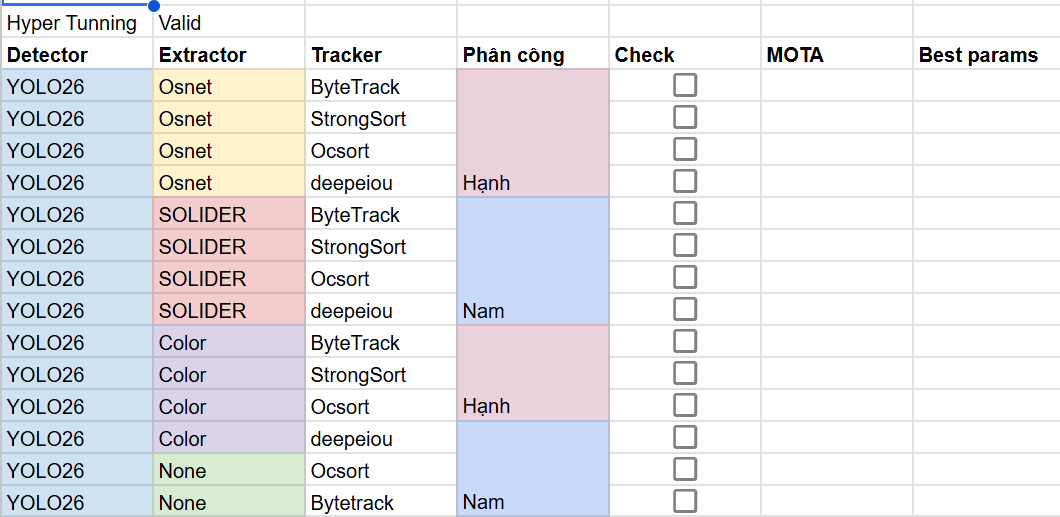

# Nam choss

# Hanh dang iu

In [7]:
import random

def sample_params(algorithm):
    if algorithm == "deepeiou":
        return {
            "track_high_thresh": random.choice([0.6, 0.65]),
            "track_low_thresh": 0.1,
            "new_track_thresh": random.choice([0.6, 0.65]),
            "track_buffer": random.choice([30, 60]),
            "match_thresh": random.choice([0.5, 0.6, 0.7]),
            "proximity_thresh": random.choice([0.5, 0.6, 0.7]), #tauma EIOU
            "appearance_thresh": random.choice([0.4, 0.5, 0.6]) #tauma A
        }
        
def generate_unique_params(algorithm, n):
    unique = set()
    results = []

    while len(results) < n:
        params = sample_params(algorithm)

        # chuyển dict -> tuple để hash được
        key = tuple(sorted(params.items()))

        if key not in unique:
            unique.add(key)
            results.append(params)

    return results

In [8]:
tracker_kwargs = generate_unique_params("deepeiou", 5)

result = tuning(
    detector=detector,
    tracker_name="deepeiou",
    tracker_kwargs=tracker_kwargs,
    extractor=extractor_osnet
)

Config:  {'track_high_thresh': 0.6, 'track_low_thresh': 0.1, 'new_track_thresh': 0.65, 'track_buffer': 30, 'match_thresh': 0.7, 'proximity_thresh': 0.5, 'appearance_thresh': 0.4}

PIPELINE: YOLO26 → OSNET → DEEPEIOU → 
Processing frame 0
Processing frame 100
Processing frame 200
Processing frame 300
Processing frame 400
Processing frame 500
Processing frame 600
Processing frame 700

[MOT] Done — 750 frames, 101 tracks
Đang đọc Ground Truth...
GT : 750 frames, 16500 objects
Pred: 750 frames, 9087 objects
Tính MOTA / MOTP / IDs...
Tính IDF1...
Tính HOTA...

       KẾT QUẢ ĐÁNH GIÁ MOT PIPELINE
  MOTA  :    44.73 %
  MOTP  :    71.30 %
  IDF1  :    52.00 %
  HOTA  :    15.64 %
  IDs   :      275
  FP    :      716
  FN    :     8129
  GT    :    16500
Done F_20200220_1_0540_0570.mp4, MOTA: 44.73

PIPELINE: YOLO26 → OSNET → DEEPEIOU → 
Processing frame 0
Processing frame 100
Processing frame 200
Processing frame 300
Processing frame 400
Processing frame 500
Processing frame 600
Processing 

KeyboardInterrupt: 